В цьому ноутбуці відбуваєтся бутстрап перевірка обраних параметрів алгоритму для досягнення оптимальних значень. Метою є перевірка значень роботи алгоритму

In [1]:
import os
os.chdir("..")

In [2]:
import pandas as pd
import random
import numpy as np
import tqdm
from scipy.stats import skew
import yaml

import seaborn as sns
import matplotlib.pyplot as plt

from app import BacktestDCA

# stocks

In [3]:
df_prices = pd.read_csv("data/test_crypto.csv", index_col=0, parse_dates=True)
df_prices.dropna(inplace=True, axis=1)
df_prices

,BTC,ETH,XRP,USDT,BCH,LTC,EOS,BNB,BSV,XLM,...,MKR,ONT,DOGE,VET,BAT,OMG,SNX,ZRX,ICX,QTUM
Date,,,,,,,,,,,,,,,,,,,,,
2020-02-13,10214.379883,268.099243,0.326706,0.998579,474.317993,80.403427,5.341575,25.440100,359.041138,0.082655,...,625.763184,1.021036,0.003026,0.008026,0.295389,1.280141,0.932967,0.320865,0.394342,2.842507
2020-02-14,10312.116211,284.217499,0.334822,1.000114,491.160645,82.990349,5.361947,26.296959,360.390015,0.085796,...,638.993713,1.071109,0.003130,0.008323,0.311020,1.370907,0.992797,0.345264,0.400229,3.015611
2020-02-15,9889.424805,264.728577,0.306236,0.999128,437.664948,76.513245,4.743118,24.149651,310.077820,0.079246,...,607.280212,0.957589,0.002920,0.007440,0.280342,1.289413,0.949770,0.317226,0.360399,2.677241
2020-02-16,9934.433594,259.894714,0.295034,0.999272,415.940643,75.152588,4.412250,23.466389,285.867523,0.075079,...,634.711975,0.909603,0.002774,0.007133,0.264260,1.190897,0.945258,0.299002,0.348740,2.511193
2020-02-17,9690.142578,266.363434,0.286572,0.998474,409.344574,73.251305,4.346360,23.551378,309.441620,0.071851,...,614.943604,0.878514,0.002712,0.006756,0.266563,1.169630,1.011205,0.291352,0.344687,2.499368
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-31,68233.312500,2104.708252,1.340259,0.999024,466.334564,53.917908,0.075516,617.049194,13.852106,0.167265,...,1740.242554,0.083272,0.092208,0.006763,0.096228,0.054769,0.287147,0.103136,0.034007,0.887649
2026-04-01,68078.554688,2138.737061,1.347766,0.999800,454.311554,53.805855,0.078632,610.622986,14.003111,0.169253,...,1785.234497,0.112436,0.092191,0.006885,0.099325,0.055448,0.281543,0.104537,0.035458,0.930321
2026-04-02,66888.570312,2056.852539,1.318691,0.999892,444.056213,52.260174,0.076542,583.136841,14.614312,0.163015,...,1750.205811,0.108114,0.090374,0.006740,0.094341,0.053399,0.278585,0.102121,0.035270,0.879604


In [4]:
configs = {
    "BuyHold": dict(strategy={"enable_sell": False}),
    "Default": dict(strategy={"enable_model": False}),
    "NoConfirm": dict(strategy={"manual_sell_fraction": 0.5, "minimum_profit": 2.0}),
}

In [5]:
n_boot = 100
sample_size = 10
sequence_length = 365 * 3

bootstrap_results = {
    strat: {"Invested": [], "Profit": [], "Returns": [], "Portfolio": [], "AvgLength": [], "MDD": [], "MDD_usd": [], "Bull_history": [], "Num_sell": [], "Banking": [], "Flow_risk": [], "Payback": [], "Value": []}
    for strat in configs
}

stocks = list(df_prices.columns)

for _ in tqdm.tqdm(range(n_boot), desc="Bootstrapping"):
    # sampled = random.sample(stocks, sample_size)
    sampled = random.choices(stocks, k=sample_size)
    equity_tmp = {k: {"Invested": 0, "Profit": 0, "Returns": 0, "Portfolio": 0, "MDD": 0, "MDD_usd": 0, "Bull_history": 0, "Num_sell": 0, "Banking": 0, "Flow_risk": 0, "Payback": 0, "Value": 0} for k in configs}
    total_length = 0
    valid_count = 0

    for stock in sampled:
        prices = df_prices[stock].dropna()

        if len(prices) < sequence_length:
            continue

        start = random.randint(0, len(prices) - sequence_length)
        prices = prices.iloc[start:start + sequence_length]
        total_length += sequence_length
        valid_count += 1

        for strat, cfg in configs.items():
            bt = BacktestDCA(
            target=stock,
            prices=prices,
            **cfg
            )
            _, metrics = bt.run()

            spent = metrics["Cash_spent"]
            returns = metrics["Cash_return"]
            mdd_pct = abs(metrics["MDD"])
            flow_returns = returns / spent
            risk_penalty = 1 + (mdd_pct / 100)
            flow_risk = flow_returns / risk_penalty

            payback = metrics['Cash_return'] / metrics['Cash_spent'] if metrics['Cash_spent'] > 0 else 0
            value = metrics['Portfolio'] + metrics['Cash_return']

            equity_tmp[strat]["Invested"] += metrics['Cash_spent']
            equity_tmp[strat]["Profit"]   += metrics['Profit']
            equity_tmp[strat]["Returns"]  += metrics['Cash_return']
            equity_tmp[strat]["Portfolio"] += metrics['Portfolio']
            equity_tmp[strat]["MDD"] += metrics["MDD"]
            equity_tmp[strat]["MDD_usd"] += metrics["MDD_usd"]
            equity_tmp[strat]['Num_sell'] += metrics['Num_take_profits']
            equity_tmp[strat]['Banking'] += metrics['Bank_profit']
            equity_tmp[strat]["Flow_risk"] += flow_risk
            equity_tmp[strat]["Bull_history"] += metrics["Bull_history"]
            equity_tmp[strat]["Payback"] += payback
            equity_tmp[strat]["Value"] += value

    if valid_count == 0:
        continue

    avg_length = total_length / valid_count

    for strat in bootstrap_results:
        bootstrap_results[strat]["Invested"].append(equity_tmp[strat]["Invested"] / valid_count)
        bootstrap_results[strat]["Profit"].append(equity_tmp[strat]["Profit"] / valid_count)
        bootstrap_results[strat]["Returns"].append(equity_tmp[strat]["Returns"] / valid_count)
        bootstrap_results[strat]["Portfolio"].append(equity_tmp[strat]["Portfolio"] / valid_count)
        bootstrap_results[strat]["AvgLength"].append(avg_length)
        bootstrap_results[strat]["MDD"].append(equity_tmp[strat]["MDD"] / valid_count)
        bootstrap_results[strat]["MDD_usd"].append(equity_tmp[strat]["MDD_usd"] / valid_count)
        bootstrap_results[strat]["Num_sell"].append(equity_tmp[strat]["Num_sell"] / valid_count)
        bootstrap_results[strat]['Banking'].append(equity_tmp[strat]['Banking'] / valid_count)
        bootstrap_results[strat]["Flow_risk"].append(equity_tmp[strat]["Flow_risk"] / valid_count)
        bootstrap_results[strat]["Bull_history"].append(equity_tmp[strat]["Bull_history"] / valid_count)
        bootstrap_results[strat]["Payback"].append(equity_tmp[strat]["Payback"] / valid_count)
        bootstrap_results[strat]["Value"].append(equity_tmp[strat]["Value"] / valid_count)

Bootstrapping: 100%|██████████| 100/100 [01:24<00:00,  1.18it/s]


In [6]:
rows = []

for strat, metrics_dict in bootstrap_results.items():
    row = {"Strategy": strat}

    for metric in ["Invested", "Profit", "Returns", "Portfolio", "MDD", "MDD_usd", "Bull_history", "Num_sell", "Banking", "Flow_risk", "Payback", "Value"]:
        arr = np.array(metrics_dict[metric])
        row[f"{metric}_mean"]    = arr.mean()
        row[f"{metric}_median"]  = np.median(arr)
        row[f"{metric}_std"]     = arr.std()
        row[f"{metric}_CI_low"]  = np.percentile(arr, 2.5)
        row[f"{metric}_CI_high"] = np.percentile(arr, 97.5)
        row[f"{metric}_skew"]    = skew(arr)

    rows.append(row)

df_bootstrap = pd.DataFrame(rows).set_index("Strategy")
df_bootstrap.round(2).T

Strategy,BuyHold,Default,NoConfirm
Invested_mean,1564.09,1564.09,1564.09
Invested_median,1564.00,1564.00,1564.00
Invested_std,1.41,1.41,1.41
Invested_CI_low,1561.48,1561.48,1561.48
Invested_CI_high,1566.52,1566.52,1566.52
...,...,...,...
Value_median,1826.55,2050.65,2072.20
Value_std,452.42,322.27,309.41
Value_CI_low,1152.23,1558.18,1560.97
Value_CI_high,2894.09,2941.61,2731.65


In [7]:
heatmap_data = df_bootstrap[[c for c in df_bootstrap.columns if "_mean" in c]].T
heatmap_data.style.background_gradient(cmap="RdYlGn", axis=1).format("{:.2f}")

Strategy,BuyHold,Default,NoConfirm
Invested_mean,1564.09,1564.09,1564.09
Profit_mean,0.00,624.94,662.16
Returns_mean,0.00,1197.74,1103.75
Portfolio_mean,1876.23,880.99,988.24
MDD_mean,-61.73,-43.95,-41.31
MDD_usd_mean,-2257.79,-690.70,-622.39
Bull_history_mean,42.57,39.38,37.30
Num_sell_mean,0.00,1.73,2.06
Banking_mean,0.00,28.43,27.37
Flow_risk_mean,0.00,0.55,0.53


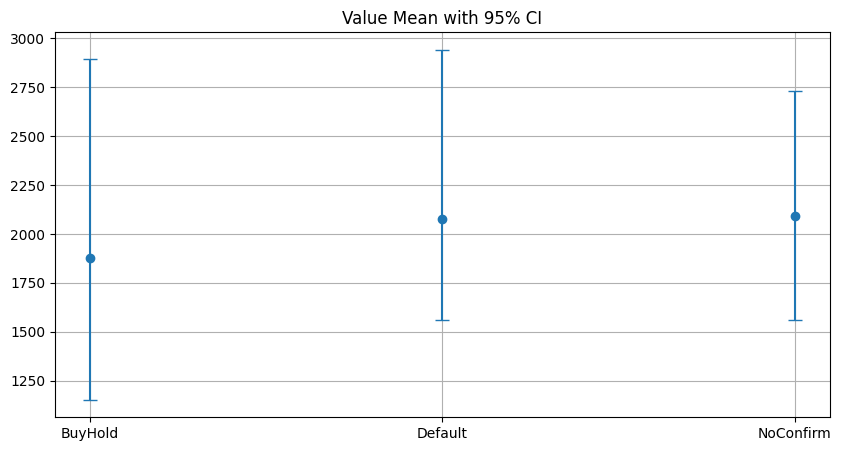

In [8]:
metric = "Value"

plt.figure(figsize=(10,5))

means = df_bootstrap[f"{metric}_mean"]
low = df_bootstrap[f"{metric}_CI_low"]
high = df_bootstrap[f"{metric}_CI_high"]

plt.errorbar(
    means.index,
    means.values,
    yerr=[means-low, high-means],
    fmt='o',
    capsize=5
)

plt.title(f"{metric} Mean with 95% CI")
plt.grid()
plt.show()

In [9]:
summary_cols = [
    "Value_mean", "Value_median", "Value_std", "Value_CI_low", "Value_CI_high", "Value_skew"
]
df_bootstrap[summary_cols].round(2).sort_values("Value_mean", ascending=False)

,Value_mean,Value_median,Value_std,Value_CI_low,Value_CI_high,Value_skew
Strategy,,,,,,
NoConfirm,2092.00,2072.20,309.41,1560.97,2731.65,0.14
Default,2078.73,2050.65,322.27,1558.18,2941.61,1.15
BuyHold,1876.23,1826.55,452.42,1152.23,2894.09,0.89
